In [2]:
import yfinance as yf
import pandas as pd

ticker = "NVDA"
start_date = "2023-01-01"
end_date = "2023-12-31"

df = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Flatten columns if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()


C:\Users\weldi\AppData\Local\Temp\ipykernel_8104\2139079314.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import talib as ta


In [7]:
df['Daily_Return'] = df['Close'].pct_change()
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1
df['RSI_14'] = ta.RSI(df['Close'], timeperiod=14)

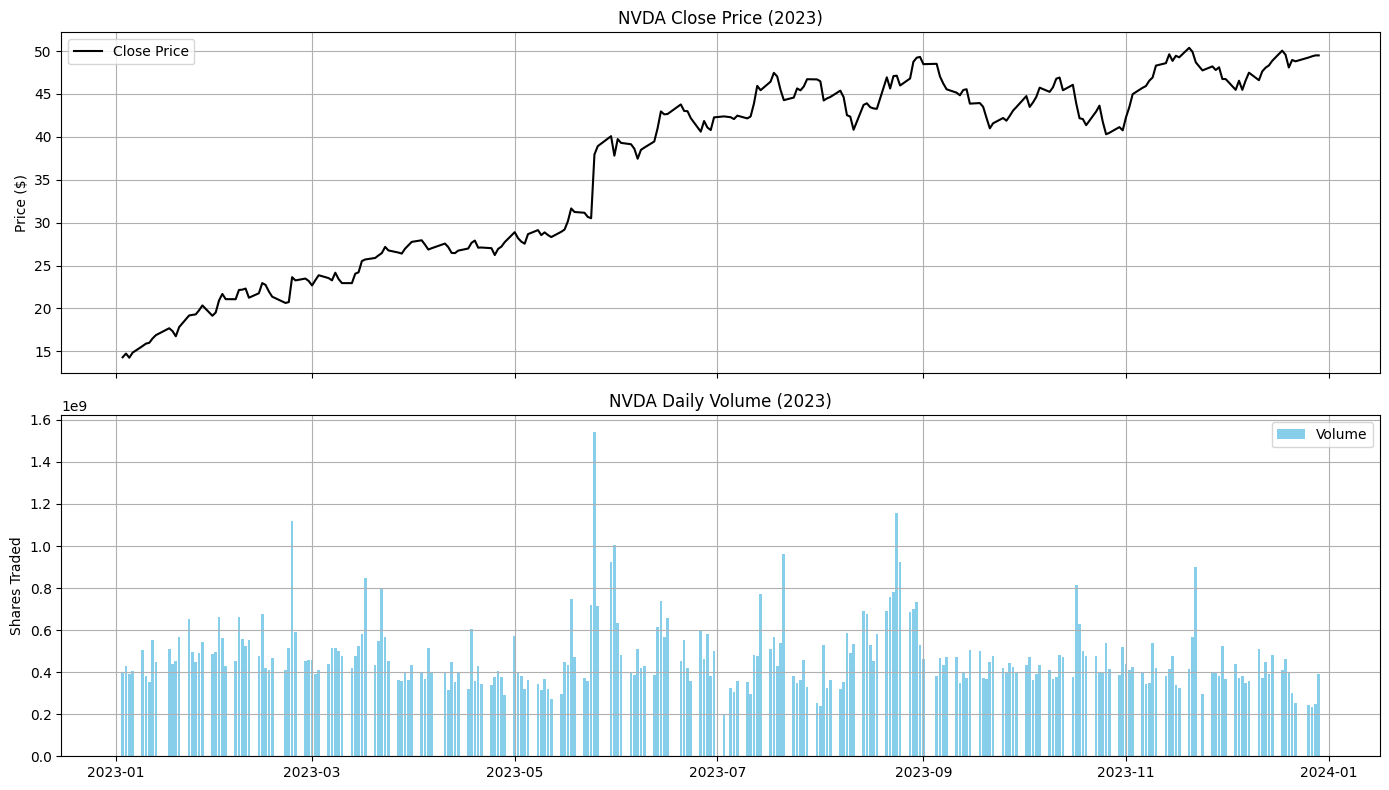

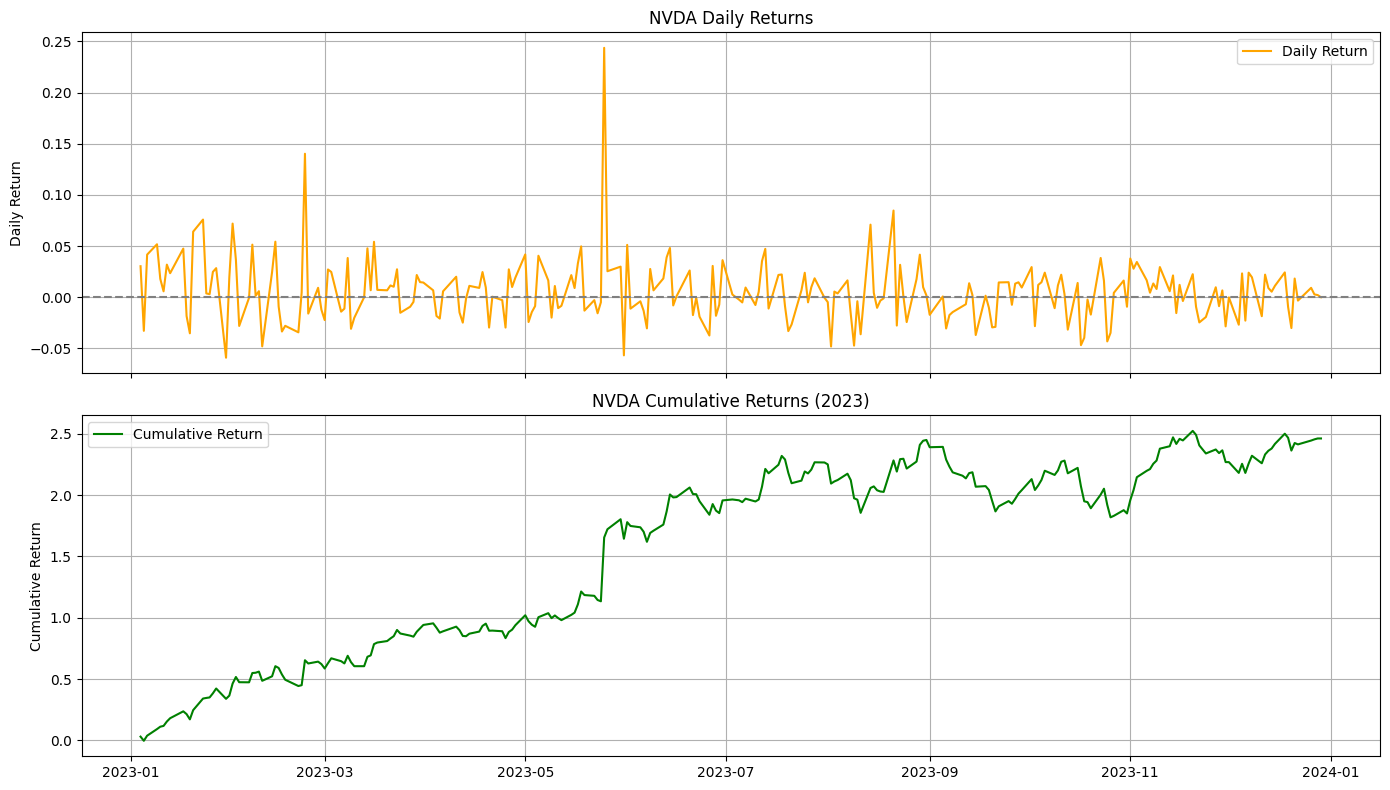

Descriptive statistics for Close, Daily Return, and Cumulative Return:
                   count       mean        std        min        25%  \
Price                                                                  
Close              250.0  36.544537  10.752565  14.251529  26.878908   
Daily_Return       249.0   0.005442   0.030525  -0.059072  -0.013069   
Cumulative_Return  249.0   1.561544   0.746836  -0.003493   0.883380   

                         50%        75%        max  
Price                                               
Close              41.867102  45.616544  50.379303  
Daily_Return        0.004315   0.021308   0.243696  
Cumulative_Return   1.928810   2.191092   2.522664  


In [9]:

# Price, Volume, Daily Returns & Cumulative Returns

import matplotlib.pyplot as plt

# --- Price & Volume ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Close price
ax1.plot(df.index, df['Close'], color='black', label='Close Price')
ax1.set_ylabel('Price ($)')
ax1.set_title('NVDA Close Price (2023)')
ax1.legend()
ax1.grid(True)

# Volume
ax2.bar(df.index, df['Volume'], color='skyblue', label='Volume')
ax2.set_ylabel('Shares Traded')
ax2.set_title('NVDA Daily Volume (2023)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


# --- Daily Returns & Cumulative Returns ---
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily Returns
ax3.plot(df.index, df['Daily_Return'], color='orange', label='Daily Return')
ax3.set_ylabel('Daily Return')
ax3.set_title('NVDA Daily Returns')
ax3.axhline(0, color='gray', linestyle='--')
ax3.legend()
ax3.grid(True)

# Cumulative Returns
ax4.plot(df.index, df['Cumulative_Return'], color='green', label='Cumulative Return')
ax4.set_ylabel('Cumulative Return')
ax4.set_title('NVDA Cumulative Returns (2023)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()


# Descriptive stats
print("Descriptive statistics for Close, Daily Return, and Cumulative Return:")
print(df[['Close','Daily_Return','Cumulative_Return']].describe().T)


In [10]:
import talib


df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)


df['RSI'] = talib.RSI(df['Close'], timeperiod=14)


df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

print(df.tail())


Price           Close       High        Low       Open     Volume  \
Date                                                                
2023-12-22  48.805531  49.358251  48.442710  49.170345  252507000   
2023-12-26  49.254303  49.575141  48.935463  48.943458  244200000   
2023-12-27  49.392231  49.655100  49.060397  49.486186  233648000   
2023-12-28  49.497181  49.858999  49.387235  49.618122  246587000   
2023-12-29  49.497181  49.971945  48.726567  49.788035  389293000   

Price       Daily_Return  Cumulative_Return     RSI_14     SMA_20     SMA_50  \
Date                                                                           
2023-12-22     -0.003266           2.412621  55.352135  47.706983  46.257776   
2023-12-26      0.009195           2.444000  57.245985  47.759019  46.334178   
2023-12-27      0.002800           2.453645  57.837925  47.838989  46.400665   
2023-12-28      0.002125           2.460983  58.310900  47.908266  46.512367   
2023-12-29      0.000000           2

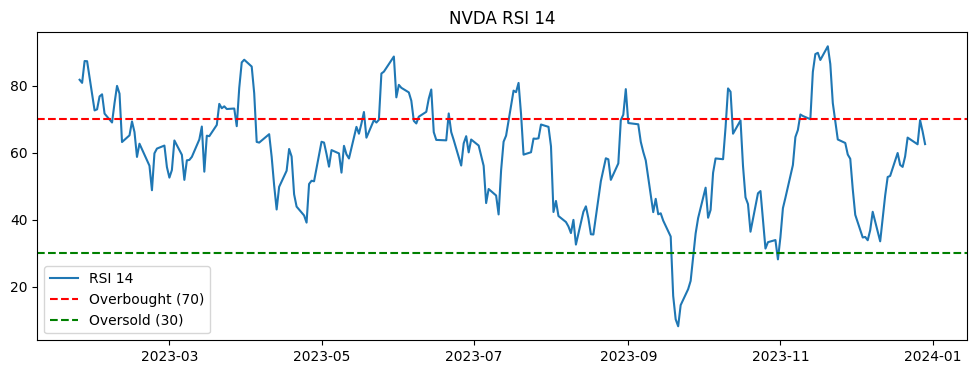

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


df['Close'] = df['Close']


delta = df['Close'].diff()

# Separate gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Calculate rolling averages
avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

# Compute RSI
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Plot RSI
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['RSI_14'], label='RSI 14')
ax.axhline(70, color='red', linestyle='--', label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', label='Oversold (30)')
ax.set_title('NVDA RSI 14')
ax.legend()
plt.show()


In [12]:
import pandas as pd


df['Daily_Return'] = df['Close'].pct_change() * 100  
df[['Close', 'Daily_Return']].head()



Price,Close,Daily_Return
Date,,
2023-01-03,14.301480,NaN
2023-01-04,14.735070,3.031784
2023-01-05,14.251529,-3.281569
2023-01-06,14.844967,4.164032
2023-01-09,15.613241,5.175318


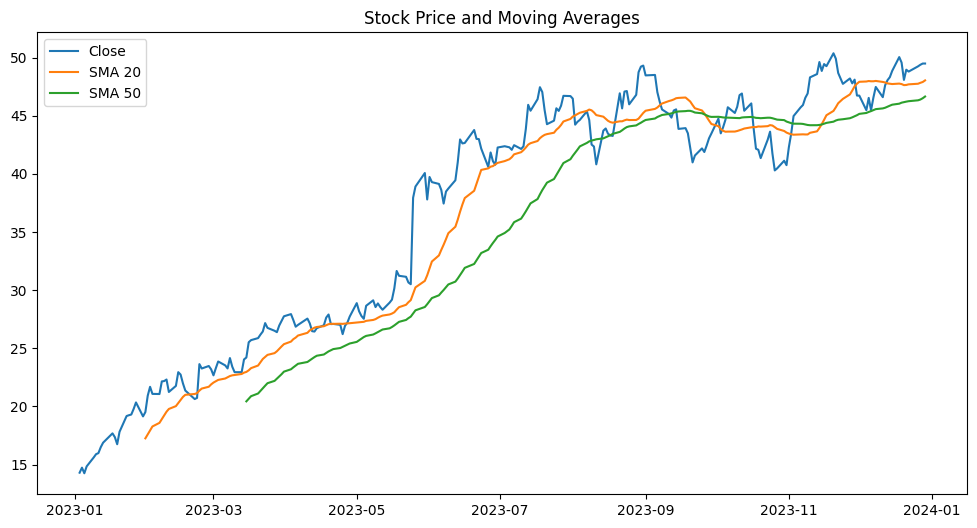

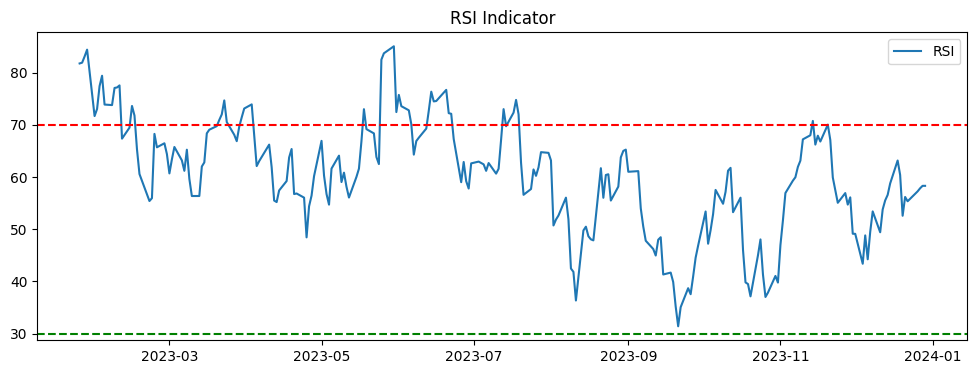

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.title('Stock Price and Moving Averages')
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('RSI Indicator')
plt.legend()
plt.show()


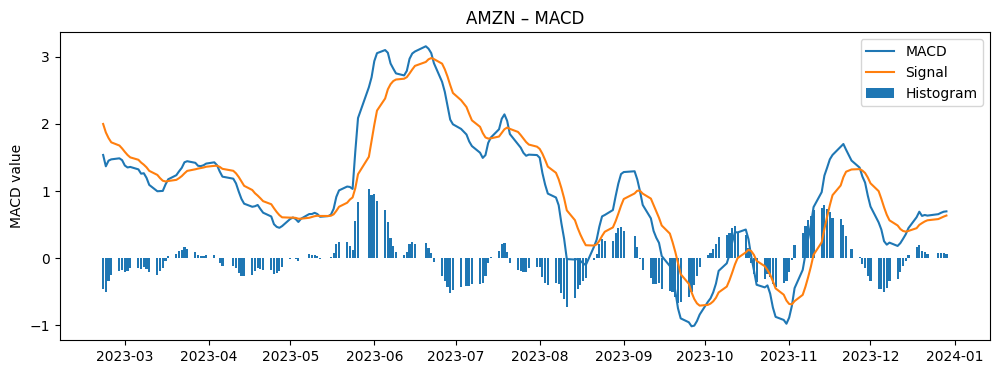

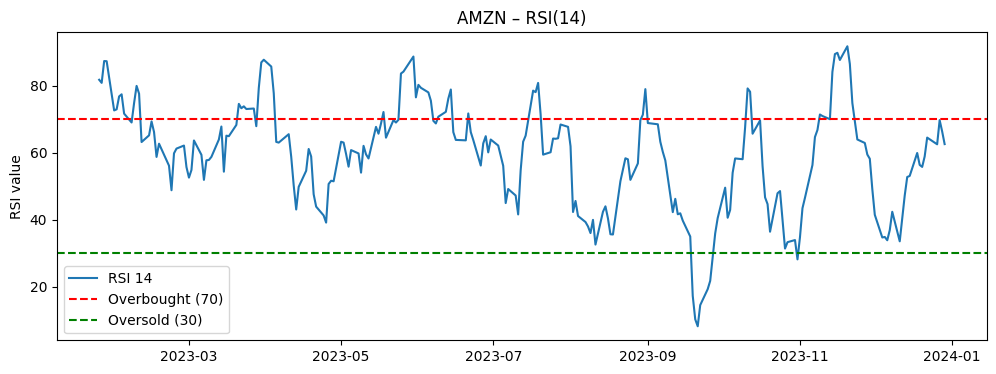

In [14]:

# MACD – Trend & momentum

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AMZN – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()



# RSI – Overbought / Oversold


fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AMZN – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


In [ ]:
# Step 5: PyNance Portfolio Metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from pynance import portfolio_optimizer as po

# Select tickers for your portfolio
ticker_list = ['TSLA', 'AAPL', 'MSFT']

# Create a PortfolioCalculations object
portfolio = po.PortfolioCalculations(ticker_list)

# Max Sharpe Portfolio
max_sharpe_rr = portfolio.max_sharpe_portfolio('rr')
max_sharpe_df = portfolio.max_sharpe_portfolio('df')
print("Max Sharpe Portfolio Risk/Return:")
print(max_sharpe_rr)
print("\nPortfolio Weights:")
print(max_sharpe_df)

# Min Variance Portfolio
min_var_rr = portfolio.min_var_portfolio('rr')
min_var_df = portfolio.min_var_portfolio('df')
print("\nMin Variance Portfolio Risk/Return:")
print(min_var_rr)
print("\nPortfolio Weights (Min Variance):")
print(min_var_df)

# Efficient Frontier Plot
fig = portfolio.efficient_frontier()
fig.show()
